In [ ]:
# %pip freeze > requirements.txt
# %pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


# 1. Initiation


#### 1.1 Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from scipy import stats

#### 1.2 Importing Daataset

In [3]:
Dataset = pd.read_excel('Combined_MPT.xlsx')

#### 1.3 Max and Min Values of Variables

In [16]:
# Print the max and min value of every variable after removing outliers
max_values = Dataset.max()  # Maximum values of each column
min_values = Dataset.min()  # Minimum values of each column

# Printing the results
print("Maximum values of each variable after removing outliers:")
print(max_values)

print("\nMinimum values of each variable after removing outliers:")
print(min_values)

Maximum values of each variable after removing outliers:
m             0.04000
p             0.40000
t             0.24000
Mach          0.04350
re      1000000.00000
AoA          15.00000
Cl            1.76240
Cd            0.22531
Cm            0.06810
dtype: float64

Minimum values of each variable after removing outliers:
m           0.010000
p           0.000000
t           0.060000
Mach        0.000435
re      10000.000000
AoA       -10.000000
Cl         -1.175700
Cd          0.000630
Cm         -0.113500
dtype: float64


#### 1.4 Input and Output Features

In [17]:
# Input and Output Features
X = Dataset[['m', 'p', 't', 'Mach', 're', 'AoA']]   # Input Features
y = Dataset[['Cl', 'Cd', 'Cm']]                   # Output Features

#### 1.5 Split the Dataset: Train, Validation, and Test

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=0)        # 80% train
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=0)  # 10% val, 10% test

#### 1.6 Data Scaling : Standardization

In [19]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(X_train)                 
X_train = sc.transform(X_train)
X_val = sc.transform(X_val)
X_test = sc.transform(X_test)


In [20]:
print (X_train)

[[ 2.2491617   0.03916993 -0.40514675 -1.37463617 -1.37463617  1.10147028]
 [-0.73201268  1.52092894  2.22335438 -0.40024114 -0.40024114 -0.91834626]
 [ 0.26171211  0.03916993 -1.36096534 -1.68783457 -1.68783457 -0.61023865]
 ...
 [-0.73201268 -1.44258909  0.07276255  0.95695193  0.95695193 -0.95258044]
 [-0.73201268  0.03916993 -0.40514675 -1.06143777 -1.06143777 -0.23366269]
 [-0.73201268  0.03916993  0.78962649  1.37454979  1.37454979  0.21138164]]


In [21]:
print (X_test)

[[-0.73201268 -0.70170958 -1.36096534  1.06135139  1.06135139  1.30687536]
 [ 1.25543691 -1.44258909 -0.64410139  0.71335317  0.71335317 -0.06249179]
 [ 1.25543691 -1.44258909  0.07276255 -0.60904008 -0.60904008 -1.39762477]
 ...
 [ 1.25543691  0.78004944 -1.36096534 -0.92223848 -0.92223848  0.48525507]
 [ 2.2491617   0.03916993 -0.40514675 -0.53944043 -0.53944043  1.30687536]
 [ 1.25543691  0.78004944 -1.36096534  0.26095548  0.26095548  1.47804625]]


In [22]:
print (X_val)

[[-0.73201268  1.52092894  2.22335438  0.6089537   0.6089537  -1.19221969]
 [ 0.26171211 -0.70170958 -0.1661921  -0.92223848 -0.92223848 -1.5003273 ]
 [ 0.26171211  1.52092894  2.22335438  1.54854891  1.54854891  0.17714746]
 ...
 [ 2.2491617   1.52092894  0.07276255  0.9221521   0.9221521   0.24561581]
 [-0.73201268  0.03916993 -0.64410139 -0.67863972 -0.67863972  1.51228043]
 [-0.73201268  1.52092894 -1.12201069 -1.68783457 -1.68783457 -1.19221969]]


# 2. Train the Models and Save

#### 2.1  Deep Neural Networks

In [23]:
# Custom R² Metric
import tensorflow.keras.backend as K

def coeff_determination(y_true, y_pred):
    SS_res = K.sum(K.square(y_true - y_pred))
    SS_tot = K.sum(K.square(y_true - K.mean(y_true)))
    return 1 - SS_res / (SS_tot + K.epsilon())

# Build the ANN Model
dnn = tf.keras.models.Sequential()
dnn.add(tf.keras.layers.Input(shape=(X_train.shape[1],)))
dnn.add(tf.keras.layers.Dense(units=128, activation='relu'))
dnn.add(tf.keras.layers.Dense(units=128, activation='relu'))
dnn.add(tf.keras.layers.Dense(units=128, activation='relu'))
dnn.add(tf.keras.layers.Dense(units=3, activation='linear'))

# Compile the ANN MOdel
import keras
dnn.compile(optimizer = 'adam',
              loss      = keras.losses.mean_squared_error,
              metrics   = ['mean_absolute_error', 'mean_absolute_percentage_error', coeff_determination])

# Define Stopping Criteria (Loss Threshold)
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',  # or 'val_loss' if you want to monitor validation loss
    patience=30,     # Number of epochs to wait before stopping
    min_delta=0.000001, # an absolute change of less than min_delta, will count as no improvement
    mode='min',      # Stop when the monitored quantity stops decreasing
    verbose=1)

# Saving the Weights with the Minimum Loss
weights_of_min_loss = tf.keras.callbacks.ModelCheckpoint(
    'best_weights.keras',      # File path where the weights will be saved
    monitor='loss',         # Monitor the loss value
    save_best_only=True,     # Save only the weights with the best (minimum) loss
    mode='min',             # Mode 'min' indicates that we want to save when loss is minimized
    verbose=1)               # Print out information about the saving process

# Training the ANN on the Training Set
history = dnn.fit(X_train, y_train,
                    batch_size = 32,
                    epochs = 1000,
                    callbacks=[early_stopping, weights_of_min_loss],
                    validation_data=(X_test, y_test),
                    verbose=1)

# Save the Model
dnn.save('cl_cd_cm_prediction_dnn.keras')

Epoch 1/1000
5557/5565 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - coeff_determination: 0.9671 - loss: 0.0065 - mean_absolute_error: 0.0331 - mean_absolute_percentage_error: 6055.8071
Epoch 1: loss improved from inf to 0.00279, saving model to best_weights.keras
5565/5565 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step - coeff_determination: 0.9671 - loss: 0.0065 - mean_absolute_error: 0.0331 - mean_absolute_percentage_error: 6051.2739 - val_coeff_determination: 0.9946 - val_loss: 0.0011 - val_mean_absolute_error: 0.0150 - val_mean_absolute_percentage_error: 4566.3262
Epoch 2/1000
5535/5565 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - coeff_determination: 0.9948 - loss: 0.0010 - mean_absolute_error: 0.0136 - mean_absolute_percentage_error: 1752.1329
Epoch 2: loss improved from 0.00279 to 0.00093, saving model to best_weights.keras
5565/5565 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - coeff_determination: 0.9948 - loss: 0.0010 - mean_absolute_error: 0.0135 - mean_absolute_percentage_error: 1751.1238 - val_coeff_determination: 0

#### 2.2 Random Forest

In [11]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200,
                           max_depth=20,
                           random_state=0
                           )

rf.fit(X_train, y_train)

# Save the model
import joblib
joblib.dump(rf, 'cl_cd_cm_prediction_rf.pkl')

['cl_cd_cm_prediction_rf.pkl']

In [ ]:
pred_rf = rf.predict(0.2, 0.5)

#### 2.3 Gradient Boosting Regression

In [12]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

base_gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=0)
gb = MultiOutputRegressor(base_gb)
gb.fit(X_train, y_train)

# Save the model
joblib.dump(gb, 'cl_cd_cm_prediction_gb.pkl')


['cl_cd_cm_prediction_gb.pkl']

#### 2.4 Multiple Polynomial Regression

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

poly = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())
poly.fit(X_train, y_train)

# Save the model
joblib.dump(poly, 'cl_cd_cm_prediction_poly.pkl')

['cl_cd_cm_prediction_poly.pkl']

# 3. Load the Models

#### Deep Neural Networks

In [17]:
from tensorflow.keras.models import load_model
loaded_dnn = load_model('cl_cd_cm_prediction_dnn.keras', custom_objects={'coeff_determination': coeff_determination})

#### Random Forest

In [18]:
loaded_rf = joblib.load('cl_cd_cm_prediction_rf.pkl')

#### Gradient Boosting Regression

In [19]:
loaded_gb = joblib.load('cl_cd_cm_prediction_gb.pkl')

#### Multiple Polynomial Regression

In [20]:
loaded_poly = joblib.load('cl_cd_cm_prediction_poly.pkl')

# 4. Predicting the Train and Test Set Results

In [ ]:
pred = dnn.predict()

#### Deep Neural Netrorks

In [21]:
y_pred_test_dnn = dnn.predict(X_test)
y_pred_train_dnn = dnn.predict(X_train)

# Printing True Values vs Predicted Values for the Test Set
results_df = pd.DataFrame({
    'True Cl': y_test['Cl'],
    'Predicted Cl': y_pred_test_dnn[:, 0],
    'True Cd': y_test['Cd'],
    'Predicted Cd': y_pred_test_dnn[:, 1],
    'True Cm': y_test['Cm'],
    'Predicted Cm': y_pred_test_dnn[:, 2]
})
print("\nTrue vs Predicted Values (Test Set):")
print(results_df)


696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 601us/step
5565/5565 ━━━━━━━━━━━━━━━━━━━━ 3s 570us/step

True vs Predicted Values (Test Set):
        True Cl  Predicted Cl  True Cd  Predicted Cd  True Cm  Predicted Cm
178729   1.3099      1.296478  0.02376      0.021073   0.0014      0.011220
158685   0.5328      0.541234  0.00769      0.010931  -0.0249     -0.026520
73270   -0.6389     -0.637560  0.01379      0.017037  -0.0156     -0.012357
80744    0.5802      0.584687  0.01054      0.012460  -0.0145     -0.016452
64154   -0.1688     -0.164149  0.01067      0.012599  -0.0167     -0.016804
...         ...           ...      ...           ...      ...           ...
61982    0.5174      0.519429  0.00879      0.007989  -0.0318     -0.033790
57463    0.8364      0.836965  0.12528      0.102607  -0.0258     -0.009738
52235    0.9675      0.969765  0.01314      0.013643  -0.0592     -0.056641
77095    1.5939      1.590570  0.02391      0.025995  -0.0476     -0.042854
127633   1.3933      1.350364  0.04134

#### Random Forest

In [22]:
y_pred_test_rf = rf.predict(X_test)
y_pred_train_rf = rf.predict(X_train)

# Printing True Values vs Predicted Values for the Test Set
results_df = pd.DataFrame({
    'True Cl': y_test['Cl'],
    'Predicted Cl': y_pred_test_rf[:, 0],
    'True Cd': y_test['Cd'],
    'Predicted Cd': y_pred_test_rf[:, 1],
    'True Cm': y_test['Cm'],
    'Predicted Cm': y_pred_test_rf[:, 2]
})
print("\nTrue vs Predicted Values (Test Set):")
print(results_df)


True vs Predicted Values (Test Set):
        True Cl  Predicted Cl  True Cd  Predicted Cd  True Cm  Predicted Cm
178729   1.3099      1.310239  0.02376      0.023796   0.0014      0.001370
158685   0.5328      0.533577  0.00769      0.007700  -0.0249     -0.025101
73270   -0.6389     -0.642014  0.01379      0.013786  -0.0156     -0.015149
80744    0.5802      0.580409  0.01054      0.010482  -0.0145     -0.014575
64154   -0.1688     -0.168737  0.01067      0.010675  -0.0167     -0.016732
...         ...           ...      ...           ...      ...           ...
61982    0.5174      0.517615  0.00879      0.008817  -0.0318     -0.031886
57463    0.8364      0.881720  0.12528      0.110836  -0.0258     -0.016218
52235    0.9675      0.967639  0.01314      0.012910  -0.0592     -0.059211
77095    1.5939      1.594261  0.02391      0.024207  -0.0476     -0.047743
127633   1.3933      1.387799  0.04134      0.043824  -0.0224     -0.021698

[22261 rows x 6 columns]


#### Gradient Boosting Regression

In [23]:
y_pred_test_gb = gb.predict(X_test)
y_pred_train_gb = gb.predict(X_train)

# Printing True Values vs Predicted Values for the Test Set
results_df = pd.DataFrame({
    'True Cl': y_test['Cl'],
    'Predicted Cl': y_pred_test_gb[:, 0],
    'True Cd': y_test['Cd'],
    'Predicted Cd': y_pred_test_gb[:, 1],
    'True Cm': y_test['Cm'],
    'Predicted Cm': y_pred_test_gb[:, 2]
})
print("\nTrue vs Predicted Values (Test Set):")
print(results_df)


True vs Predicted Values (Test Set):
        True Cl  Predicted Cl  True Cd  Predicted Cd  True Cm  Predicted Cm
178729   1.3099      1.323048  0.02376      0.022342   0.0014      0.003688
158685   0.5328      0.530689  0.00769      0.007267  -0.0249     -0.023462
73270   -0.6389     -0.652321  0.01379      0.013661  -0.0156     -0.016129
80744    0.5802      0.594440  0.01054      0.007823  -0.0145     -0.015594
64154   -0.1688     -0.180525  0.01067      0.010769  -0.0167     -0.014447
...         ...           ...      ...           ...      ...           ...
61982    0.5174      0.526616  0.00879      0.009488  -0.0318     -0.032151
57463    0.8364      0.993660  0.12528      0.080381  -0.0258     -0.001299
52235    0.9675      0.952930  0.01314      0.013218  -0.0592     -0.058456
77095    1.5939      1.579863  0.02391      0.025015  -0.0476     -0.044982
127633   1.3933      1.409141  0.04134      0.037190  -0.0224     -0.019974

[22261 rows x 6 columns]


#### Multiple Polynomial Regression

In [24]:
y_pred_test_poly = poly.predict(X_test)
y_pred_train_poly = poly.predict(X_train)

# Printing True Values vs Predicted Values for the Test Set
results_df = pd.DataFrame({
    'True Cl': y_test['Cl'],
    'Predicted Cl': y_pred_test_poly[:, 0],
    'True Cd': y_test['Cd'],
    'Predicted Cd': y_pred_test_poly[:, 1],
    'True Cm': y_test['Cm'],
    'Predicted Cm': y_pred_test_poly[:, 2]
})
print("\nTrue vs Predicted Values (Test Set):")
print(results_df)


True vs Predicted Values (Test Set):
        True Cl  Predicted Cl  True Cd  Predicted Cd  True Cm  Predicted Cm
178729   1.3099      1.240698  0.02376      0.030294   0.0014      0.000794
158685   0.5328      0.480294  0.00769      0.007358  -0.0249     -0.023067
73270   -0.6389     -0.518294  0.01379      0.016713  -0.0156     -0.021245
80744    0.5802      0.625516  0.01054      0.005173  -0.0145     -0.016976
64154   -0.1688     -0.163960  0.01067      0.005861  -0.0167     -0.014306
...         ...           ...      ...           ...      ...           ...
61982    0.5174      0.480848  0.00879      0.003054  -0.0318     -0.028371
57463    0.8364      1.109517  0.12528      0.069643  -0.0258      0.001932
52235    0.9675      0.917606  0.01314      0.012850  -0.0592     -0.056408
77095    1.5939      1.473152  0.02391      0.035882  -0.0476     -0.043463
127633   1.3933      1.444902  0.04134      0.037287  -0.0224     -0.023495

[22261 rows x 6 columns]


# 5. Errors Measurement of Train and Test Set

#### Deep Neural Netrorks

In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
train_mse = mean_squared_error(y_train, y_pred_train_dnn)
train_mae = mean_absolute_error(y_train, y_pred_train_dnn)
train_r_squared = r2_score(y_train, y_pred_train_dnn)

print(f"\nMean Squared Error (MSE) of Train Set: {train_mse:.5f}")
print(f"Mean Absolute Error (MAE) of Train Set: {train_mae:.5f}")
print(f"R-squared (R²) of Train Set: {train_r_squared:.5f}")

test_mse = mean_squared_error(y_test, y_pred_test_dnn)
test_mae = mean_absolute_error(y_test, y_pred_test_dnn)
test_r_squared = r2_score(y_test, y_pred_test_dnn)

print(f"\nMean Squared Error (MSE) of Test Set: {test_mse:.5f}")
print(f"Mean Absolute Error (MAE) of Test Set: {test_mae:.5f}")
print(f"R-squared (R²) of Test Set: {test_r_squared:.5f}")


Mean Squared Error (MSE) of Train Set: 0.00017
Mean Absolute Error (MAE) of Train Set: 0.00600
R-squared (R²) of Train Set: 0.97955

Mean Squared Error (MSE) of Test Set: 0.00022
Mean Absolute Error (MAE) of Test Set: 0.00627
R-squared (R²) of Test Set: 0.97749


#### Random Forest

In [26]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
train_mse = mean_squared_error(y_train, y_pred_train_rf)
train_mae = mean_absolute_error(y_train, y_pred_train_rf)
train_r_squared = r2_score(y_train, y_pred_train_rf)

print(f"\nMean Squared Error (MSE) of Train Set: {train_mse:.5f}")
print(f"Mean Absolute Error (MAE) of Train Set: {train_mae:.5f}")
print(f"R-squared (R²) of Train Set: {train_r_squared:.5f}")

test_mse = mean_squared_error(y_test, y_pred_test_rf)
test_mae = mean_absolute_error(y_test, y_pred_test_rf)
test_r_squared = r2_score(y_test, y_pred_test_rf)

print(f"\nMean Squared Error (MSE) of Test Set: {test_mse:.5f}")
print(f"Mean Absolute Error (MAE) of Test Set: {test_mae:.5f}")
print(f"R-squared (R²) of Test Set: {test_r_squared:.5f}")


Mean Squared Error (MSE) of Train Set: 0.00002
Mean Absolute Error (MAE) of Train Set: 0.00103
R-squared (R²) of Train Set: 0.99891

Mean Squared Error (MSE) of Test Set: 0.00011
Mean Absolute Error (MAE) of Test Set: 0.00240
R-squared (R²) of Test Set: 0.99282


#### Gradient Boosting Regression

In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
train_mse = mean_squared_error(y_train, y_pred_train_gb)
train_mae = mean_absolute_error(y_train, y_pred_train_gb)
train_r_squared = r2_score(y_train, y_pred_train_gb)

print(f"\nMean Squared Error (MSE) of Train Set: {train_mse:.5f}")
print(f"Mean Absolute Error (MAE) of Train Set: {train_mae:.5f}")
print(f"R-squared (R²) of Train Set: {train_r_squared:.5f}")

test_mse = mean_squared_error(y_test, y_pred_test_gb)
test_mae = mean_absolute_error(y_test, y_pred_test_gb)
test_r_squared = r2_score(y_test, y_pred_test_gb)

print(f"\nMean Squared Error (MSE) of Test Set: {test_mse:.5f}")
print(f"Mean Absolute Error (MAE) of Test Set: {test_mae:.5f}")
print(f"R-squared (R²) of Test Set: {test_r_squared:.5f}")


Mean Squared Error (MSE) of Train Set: 0.00057
Mean Absolute Error (MAE) of Train Set: 0.00990
R-squared (R²) of Train Set: 0.97272

Mean Squared Error (MSE) of Test Set: 0.00061
Mean Absolute Error (MAE) of Test Set: 0.01007
R-squared (R²) of Test Set: 0.97124


#### Multiple Polynomial Regression

In [28]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
train_mse = mean_squared_error(y_train, y_pred_train_poly)
train_mae = mean_absolute_error(y_train, y_pred_train_poly)
train_r_squared = r2_score(y_train, y_pred_train_poly)

print(f"\nMean Squared Error (MSE) of Train Set: {train_mse:.5f}")
print(f"Mean Absolute Error (MAE) of Train Set: {train_mae:.5f}")
print(f"R-squared (R²) of Train Set: {train_r_squared:.5f}")

test_mse = mean_squared_error(y_test, y_pred_test_poly)
test_mae = mean_absolute_error(y_test, y_pred_test_poly)
test_r_squared = r2_score(y_test, y_pred_test_poly)

print(f"\nMean Squared Error (MSE) of Test Set: {test_mse:.5f}")
print(f"Mean Absolute Error (MAE) of Test Set: {test_mae:.5f}")
print(f"R-squared (R²) of Test Set: {test_r_squared:.5f}")


Mean Squared Error (MSE) of Train Set: 0.00370
Mean Absolute Error (MAE) of Train Set: 0.02713
R-squared (R²) of Train Set: 0.85764

Mean Squared Error (MSE) of Test Set: 0.00376
Mean Absolute Error (MAE) of Test Set: 0.02728
R-squared (R²) of Test Set: 0.85862


# 6. Plot the Training and Test Loss Values

#### Deep Neural Netrorks

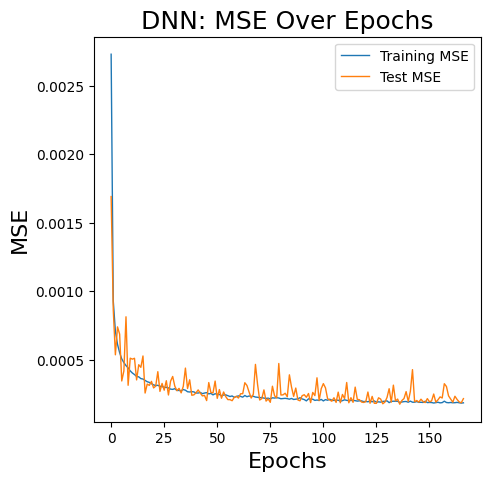

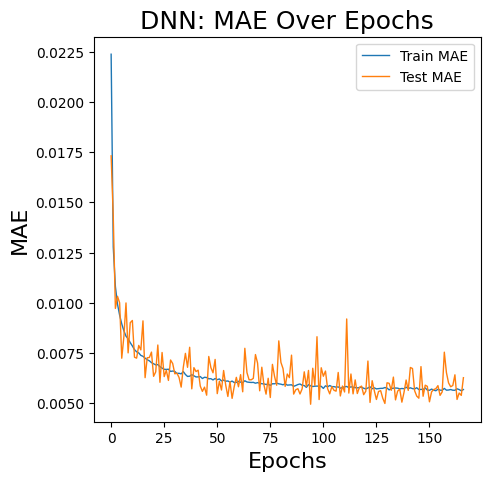

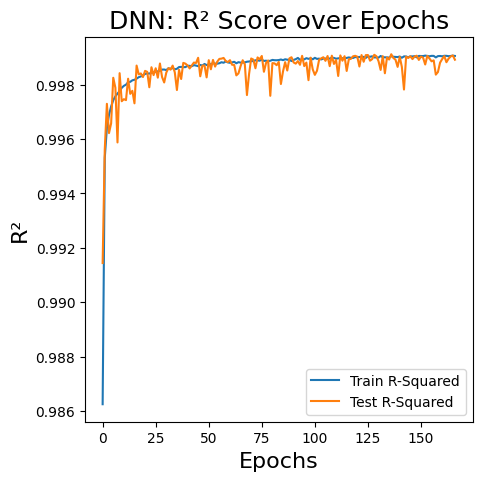

In [88]:
# MSE over Epochs
plt.figure(figsize=(5,5))
plt.plot(history.history['loss'], label='Training MSE',lw = 1,)
plt.plot(history.history['val_loss'], label='Test MSE', lw = 1,)
plt.title('DNN: MSE Over Epochs', fontsize=18)
plt.ylabel('MSE', fontsize=16)
plt.xlabel('Epochs', fontsize=16)
plt.legend()
plt.show()

# MAE over Epochs
plt.figure(figsize=(5, 5))
plt.plot(history.history['mean_absolute_error'], label='Train MAE', lw=1)
plt.plot(history.history['val_mean_absolute_error'], label='Test MAE', lw=1)
plt.title('DNN: MAE Over Epochs', fontsize=18)
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('MAE', fontsize=16)
plt.legend()
plt.grid(False)
plt.show()

# R-Squared over Epochs
plt.figure(figsize=(5, 5))
plt.plot(history.history['coeff_determination'], label='Train R-Squared')
plt.plot(history.history['val_coeff_determination'], label='Test R-Squared')
plt.title('DNN: R² Score over Epochs', fontsize=18)
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('R²', fontsize=16)
plt.legend()
plt.grid(False)
plt.show()

#### Random Forest

In [34]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

n_estimators_list = list(range(10, 201, 10))
train_mse_rf, test_mse_rf = [], []
train_mae_rf, test_mae_rf = [], []
train_r2_rf, test_r2_rf = [], []

for n in n_estimators_list:
    rf = RandomForestRegressor(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    
    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)
    
    train_mse_rf.append(mean_squared_error(y_train, y_train_pred))
    test_mse_rf.append(mean_squared_error(y_test, y_test_pred))
    
    train_mae_rf.append(mean_absolute_error(y_train, y_train_pred))
    test_mae_rf.append(mean_absolute_error(y_test, y_test_pred))
    
    train_r2_rf.append(r2_score(y_train, y_train_pred))
    test_r2_rf.append(r2_score(y_test, y_test_pred))


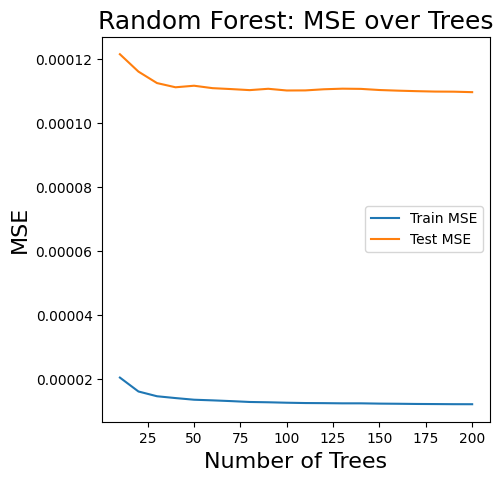

In [85]:
# Plotting
plt.figure(figsize=(5,5))
plt.plot(n_estimators_list, train_mse_rf, label="Train MSE")
plt.plot(n_estimators_list, test_mse_rf, label="Test MSE")
plt.xlabel("Number of Trees",fontsize=16)
plt.ylabel("MSE",fontsize=16)
plt.title("Random Forest: MSE over Trees",fontsize=18)
plt.legend()

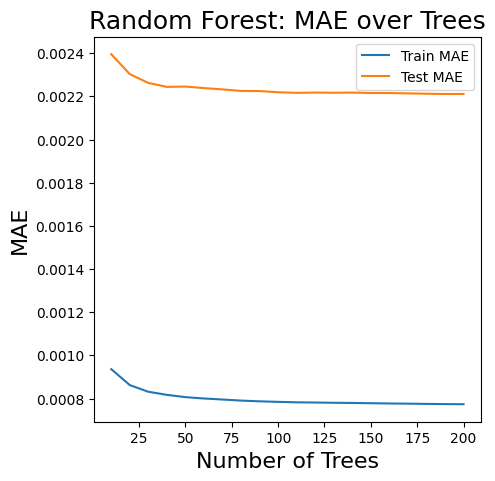

In [86]:
plt.figure(figsize=(5,5))
plt.plot(n_estimators_list, train_mae_rf, label="Train MAE")
plt.plot(n_estimators_list, test_mae_rf, label="Test MAE")
plt.xlabel("Number of Trees",fontsize=16)
plt.ylabel("MAE",fontsize=16)
plt.title("Random Forest: MAE over Trees",fontsize=18)
plt.legend()

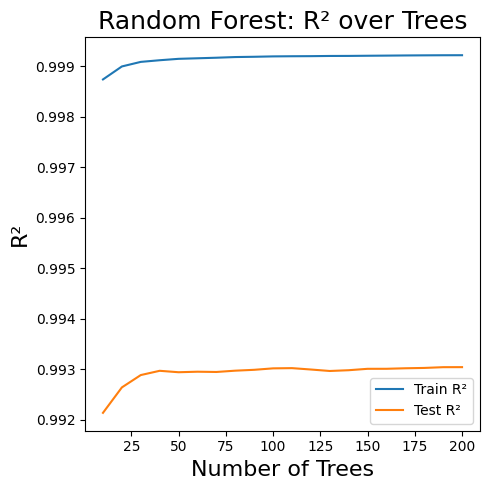

In [87]:
plt.figure(figsize=(5, 5))
plt.plot(n_estimators_list, train_r2_rf, label="Train R²")
plt.plot(n_estimators_list, test_r2_rf, label="Test R²")
plt.xlabel("Number of Trees",fontsize=16)
plt.ylabel("R²",fontsize=16)
plt.title("Random Forest: R² over Trees",fontsize=18)
plt.legend()

plt.tight_layout()
plt.show()

#### Gradient Boosting Regression

In [48]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

n_estimators_list = list(range(10, 201, 10))
train_mse_gb, test_mse_gb = [], []
train_mae_gb, test_mae_gb = [], []
train_r2_gb, test_r2_gb = [], []

for n in n_estimators_list:
    base_gb = GradientBoostingRegressor(n_estimators=n, random_state=42)
    gb = MultiOutputRegressor(base_gb)
    gb.fit(X_train, y_train)
    
    y_train_pred = gb.predict(X_train)
    y_test_pred = gb.predict(X_test)
    
    train_mse_gb.append(mean_squared_error(y_train, y_train_pred))
    test_mse_gb.append(mean_squared_error(y_test, y_test_pred))
    
    train_mae_gb.append(mean_absolute_error(y_train, y_train_pred))
    test_mae_gb.append(mean_absolute_error(y_test, y_test_pred))
    
    train_r2_gb.append(r2_score(y_train, y_train_pred))
    test_r2_gb.append(r2_score(y_test, y_test_pred))


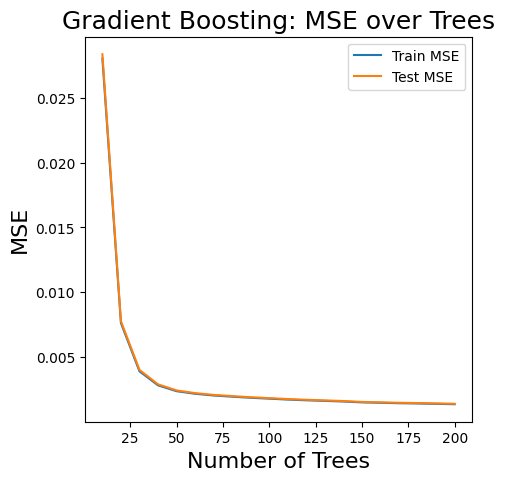

In [89]:
# Plotting
plt.figure(figsize=(5, 5))
plt.plot(n_estimators_list, train_mse_gb, label="Train MSE")
plt.plot(n_estimators_list, test_mse_gb, label="Test MSE")
plt.xlabel("Number of Trees",fontsize=16)
plt.ylabel("MSE",fontsize=16)
plt.title("Gradient Boosting: MSE over Trees",fontsize=18)
plt.legend()
plt.show()

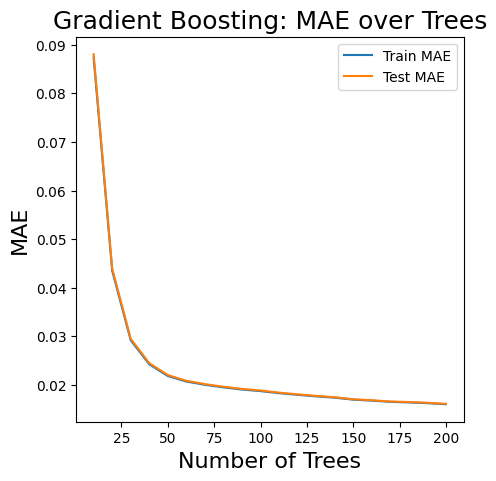

In [90]:
plt.figure(figsize=(5, 5))
plt.plot(n_estimators_list, train_mae_gb, label="Train MAE")
plt.plot(n_estimators_list, test_mae_gb, label="Test MAE")
plt.xlabel("Number of Trees",fontsize=16)
plt.ylabel("MAE",fontsize=16)
plt.title("Gradient Boosting: MAE over Trees",fontsize=18)
plt.legend()
plt.show()


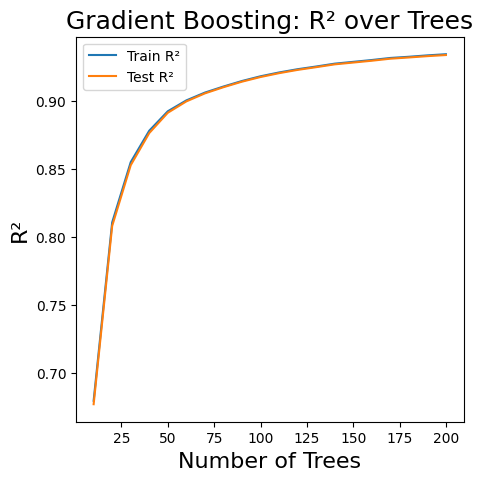

In [91]:
plt.figure(figsize=(5, 5))
plt.plot(n_estimators_list, train_r2_gb, label="Train R²")
plt.plot(n_estimators_list, test_r2_gb, label="Test R²")
plt.xlabel("Number of Trees",fontsize=16)
plt.ylabel("R²",fontsize=16)
plt.title("Gradient Boosting: R² over Trees",fontsize=18)
plt.legend()
plt.show()

#### Multiple Polynomial Regression

In [57]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

degrees = list(range(1, 8))
train_mse_pr, test_mse_pr = [], []
train_mae_pr, test_mae_pr = [], []
train_r2_pr, test_r2_pr = [], []

for degree in degrees:
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_mse_pr.append(mean_squared_error(y_train, y_train_pred))
    test_mse_pr.append(mean_squared_error(y_test, y_test_pred))
    
    train_mae_pr.append(mean_absolute_error(y_train, y_train_pred))
    test_mae_pr.append(mean_absolute_error(y_test, y_test_pred))
    
    train_r2_pr.append(r2_score(y_train, y_train_pred))
    test_r2_pr.append(r2_score(y_test, y_test_pred))

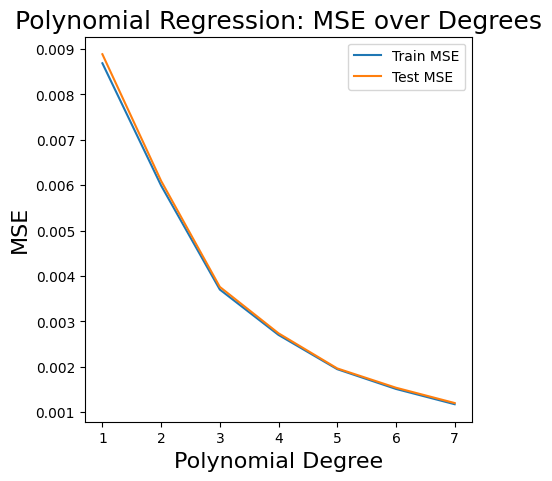

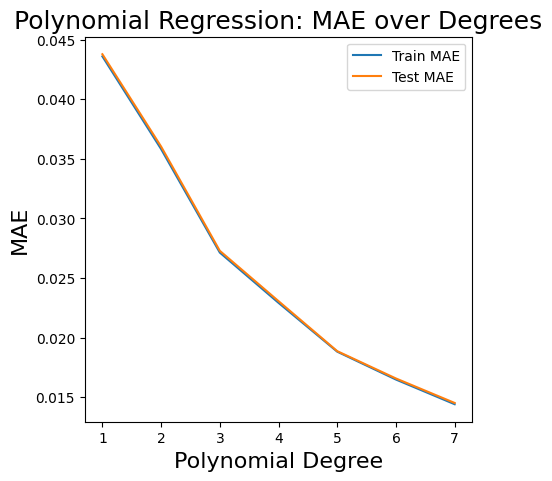

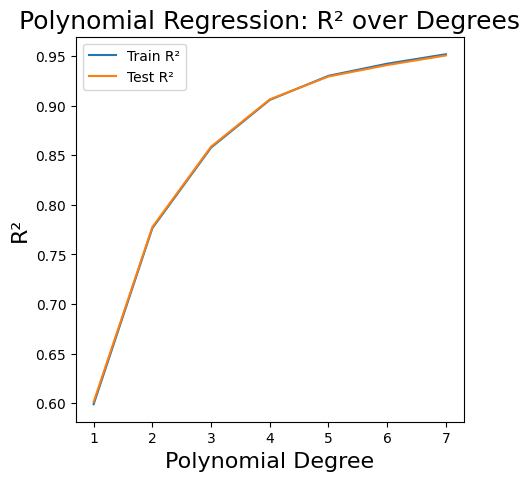

In [92]:
# Plotting
plt.figure(figsize=(5, 5))
plt.plot(degrees, train_mse_pr, label="Train MSE")
plt.plot(degrees, test_mse_pr, label="Test MSE")
plt.xlabel("Polynomial Degree",fontsize=16)
plt.ylabel("MSE",fontsize=16)
plt.title("Polynomial Regression: MSE over Degrees",fontsize=18)
plt.legend()
plt.show()

plt.figure(figsize=(5, 5))
plt.plot(degrees, train_mae_pr, label="Train MAE")
plt.plot(degrees, test_mae_pr, label="Test MAE")
plt.xlabel("Polynomial Degree",fontsize=16)
plt.ylabel("MAE",fontsize=16)
plt.title("Polynomial Regression: MAE over Degrees",fontsize=18)
plt.legend()
plt.show()

plt.figure(figsize=(5, 5))
plt.plot(degrees, train_r2_pr, label="Train R²")
plt.plot(degrees, test_r2_pr, label="Test R²")
plt.xlabel("Polynomial Degree",fontsize=16)
plt.ylabel("R²",fontsize=16)
plt.title("Polynomial Regression: R² over Degrees",fontsize=18)
plt.legend()
plt.show()
plt.show()

# 7. Plot: Predicted vs True Values

#### Deep Neural Networks

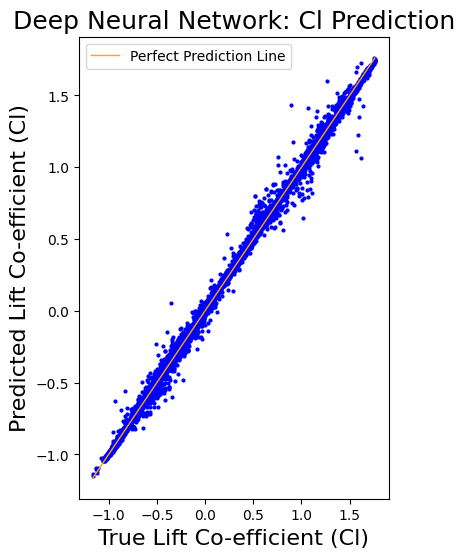

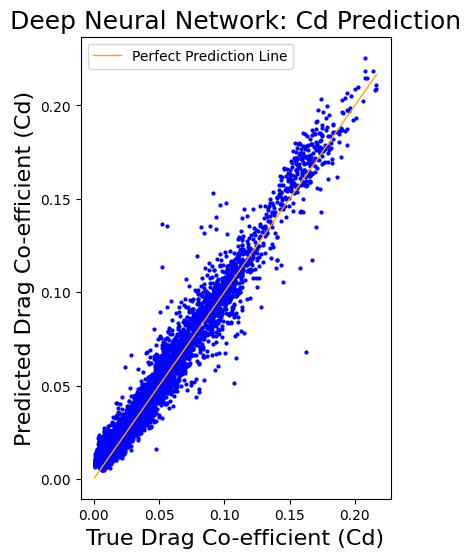

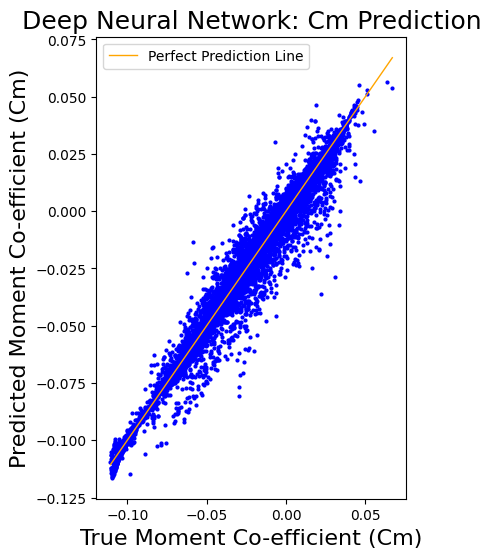

In [93]:
# Predicted Cl vs True Cl
plt.figure(figsize=(4, 6))
plt.scatter(y_test['Cl'], y_pred_test_dnn[:, 0], color='blue', s=4) 
plt.plot([min(y_test['Cl']), max(y_test['Cl'])], 
         [min(y_test['Cl']), max(y_test['Cl'])], 
         color='orange', lw=1, label='Perfect Prediction Line')
plt.title('Deep Neural Network: Cl Prediction', fontsize=18)
plt.xlabel('True Lift Co-efficient (Cl)', fontsize=16)
plt.ylabel('Predicted Lift Co-efficient (Cl)', fontsize=16)
plt.legend()
plt.grid(False)
plt.show()

# Predicted Cd vs True Cd
plt.figure(figsize=(4, 6))
plt.scatter(y_test['Cd'], y_pred_test_dnn[:, 1], color='blue', s=4)
plt.plot([min(y_test['Cd']), max(y_test['Cd'])], 
         [min(y_test['Cd']), max(y_test['Cd'])], 
         color='orange', lw=1, label='Perfect Prediction Line')
plt.title('Deep Neural Network: Cd Prediction', fontsize=18)
plt.xlabel('True Drag Co-efficient (Cd)', fontsize=16)
plt.ylabel('Predicted Drag Co-efficient (Cd)', fontsize=16)
plt.legend()
plt.grid(False)
plt.show()

# Predicted Cm vs True Cm
plt.figure(figsize=(4, 6))
plt.scatter(y_test['Cm'], y_pred_test_dnn[:, 2], color='blue', s=4)
plt.plot([min(y_test['Cm']), max(y_test['Cm'])], 
         [min(y_test['Cm']), max(y_test['Cm'])], 
         color='orange', lw=1, label='Perfect Prediction Line')
plt.title('Deep Neural Network: Cm Prediction', fontsize=18)
plt.xlabel('True Moment Co-efficient (Cm)', fontsize=16)
plt.ylabel('Predicted Moment Co-efficient (Cm)', fontsize=16)
plt.legend()
plt.grid(False)
plt.show()

#### Random Forest

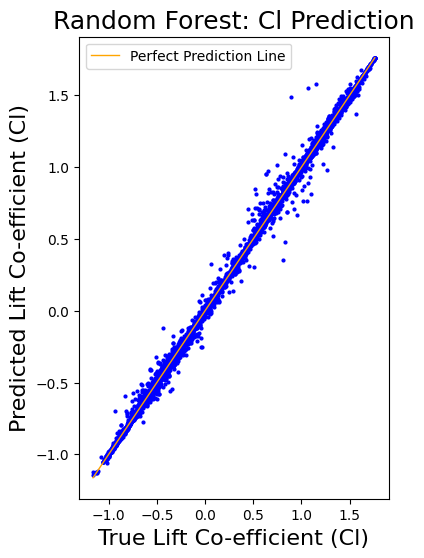

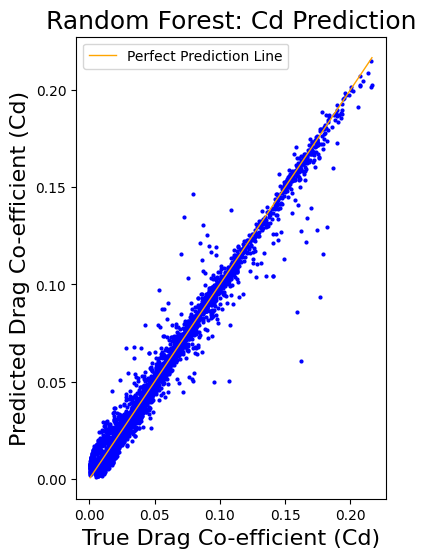

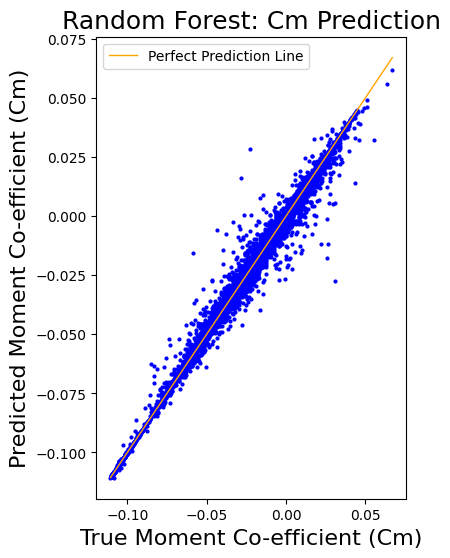

In [94]:
# Predicted Cl vs True Cl
plt.figure(figsize=(4, 6))
plt.scatter(y_test['Cl'], y_pred_test_rf[:, 0], color='blue', s=4)  
plt.plot([min(y_test['Cl']), max(y_test['Cl'])], 
         [min(y_test['Cl']), max(y_test['Cl'])], 
         color='orange', lw=1, label='Perfect Prediction Line')
plt.title('Random Forest: Cl Prediction', fontsize=18)
plt.xlabel('True Lift Co-efficient (Cl)', fontsize=16)
plt.ylabel('Predicted Lift Co-efficient (Cl)', fontsize=16)
plt.legend()
plt.grid(False)
plt.show()

# Predicted Cd vs True Cd
plt.figure(figsize=(4, 6))
plt.scatter(y_test['Cd'], y_pred_test_rf[:, 1], color='blue', s=4) 
plt.plot([min(y_test['Cd']), max(y_test['Cd'])], 
         [min(y_test['Cd']), max(y_test['Cd'])], 
         color='orange', lw=1, label='Perfect Prediction Line')
plt.title('Random Forest: Cd Prediction', fontsize=18)
plt.xlabel('True Drag Co-efficient (Cd)', fontsize=16)
plt.ylabel('Predicted Drag Co-efficient (Cd)', fontsize=16)
plt.legend()
plt.grid(False)
plt.show()

# Predicted Cm vs True Cm
plt.figure(figsize=(4, 6))
plt.scatter(y_test['Cm'], y_pred_test_rf[:, 2], color='blue', s=4)
plt.plot([min(y_test['Cm']), max(y_test['Cm'])], 
         [min(y_test['Cm']), max(y_test['Cm'])], 
         color='orange', lw=1, label='Perfect Prediction Line')
plt.title('Random Forest: Cm Prediction', fontsize=18)
plt.xlabel('True Moment Co-efficient (Cm)', fontsize=16)
plt.ylabel('Predicted Moment Co-efficient (Cm)', fontsize=16)
plt.legend()
plt.grid(False)
plt.show()

#### Gradient Boosting

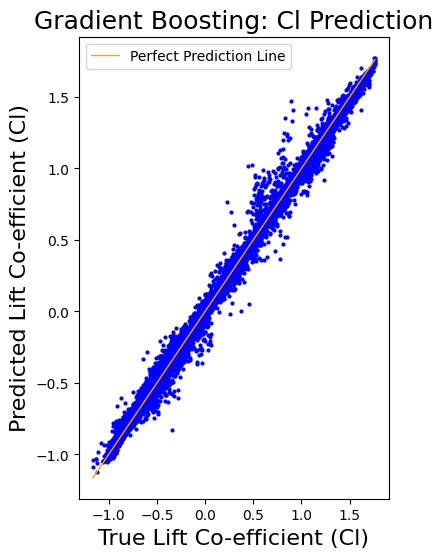

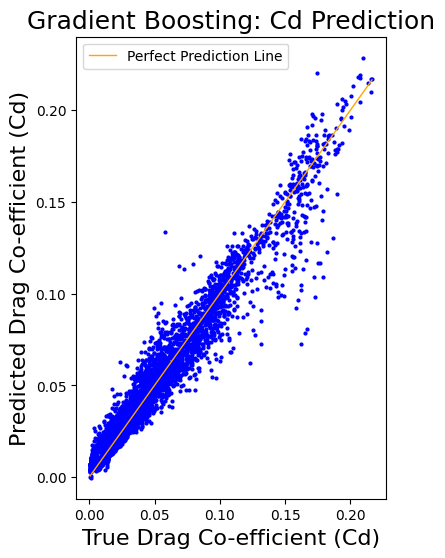

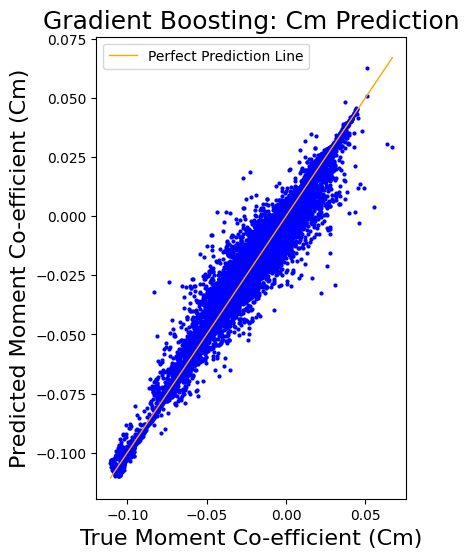

In [96]:
# Predicted Cl vs True Cl
plt.figure(figsize=(4, 6))
plt.scatter(y_test['Cl'], y_pred_test_gb[:, 0], color='blue', s=4)  
plt.plot([min(y_test['Cl']), max(y_test['Cl'])], 
         [min(y_test['Cl']), max(y_test['Cl'])], 
         color='orange', lw=1, label='Perfect Prediction Line')
plt.title('Gradient Boosting: Cl Prediction', fontsize=18)
plt.xlabel('True Lift Co-efficient (Cl)', fontsize=16)
plt.ylabel('Predicted Lift Co-efficient (Cl)', fontsize=16)
plt.legend()
plt.grid(False)
plt.show()

# Predicted Cd vs True Cd
plt.figure(figsize=(4, 6))
plt.scatter(y_test['Cd'], y_pred_test_gb[:, 1], color='blue', s=4) 
plt.plot([min(y_test['Cd']), max(y_test['Cd'])], 
         [min(y_test['Cd']), max(y_test['Cd'])], 
         color='orange', lw=1, label='Perfect Prediction Line')
plt.title('Gradient Boosting: Cd Prediction', fontsize=18)
plt.xlabel('True Drag Co-efficient (Cd)', fontsize=16)
plt.ylabel('Predicted Drag Co-efficient (Cd)', fontsize=16)
plt.legend()
plt.grid(False)
plt.show()

# Predicted Cm vs True Cm
plt.figure(figsize=(4, 6))
plt.scatter(y_test['Cm'], y_pred_test_gb[:, 2], color='blue', s=4)
plt.plot([min(y_test['Cm']), max(y_test['Cm'])], 
         [min(y_test['Cm']), max(y_test['Cm'])], 
         color='orange', lw=1, label='Perfect Prediction Line')
plt.title('Gradient Boosting: Cm Prediction', fontsize=18)
plt.xlabel('True Moment Co-efficient (Cm)', fontsize=16)
plt.ylabel('Predicted Moment Co-efficient (Cm)', fontsize=16)
plt.legend()
plt.grid(False)
plt.show()

#### polynomial Regression

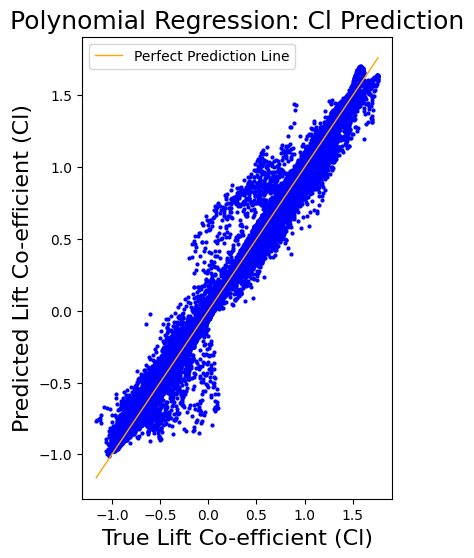

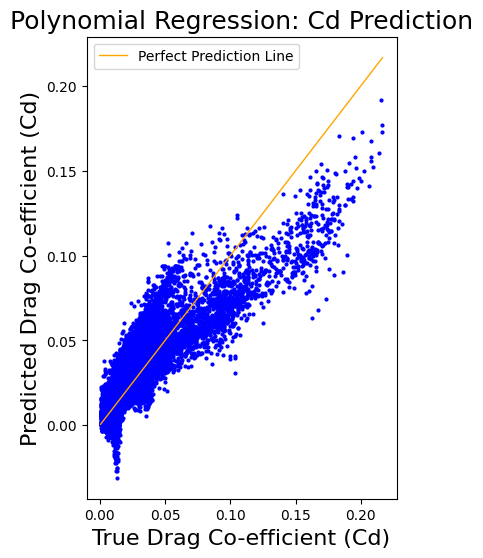

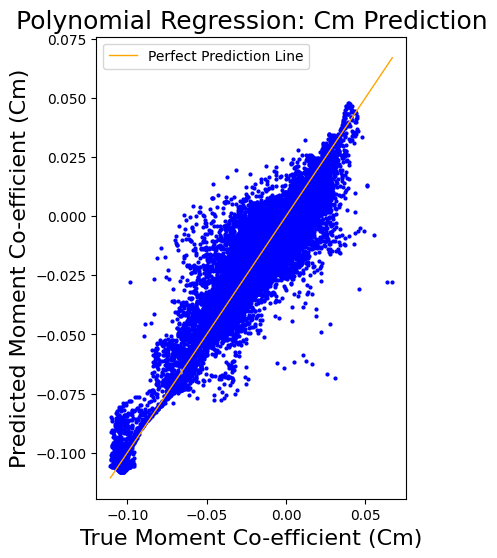

In [95]:
# Predicted Cl vs True Cl
plt.figure(figsize=(4, 6))
plt.scatter(y_test['Cl'], y_pred_test_poly[:, 0], color='blue', s=4)  
plt.plot([min(y_test['Cl']), max(y_test['Cl'])], 
         [min(y_test['Cl']), max(y_test['Cl'])], 
         color='orange', lw=1, label='Perfect Prediction Line')
plt.title('Polynomial Regression: Cl Prediction', fontsize=18)
plt.xlabel('True Lift Co-efficient (Cl)', fontsize=16)
plt.ylabel('Predicted Lift Co-efficient (Cl)', fontsize=16)
plt.legend()
plt.grid(False)
plt.show()

# Predicted Cd vs True Cd
plt.figure(figsize=(4, 6))
plt.scatter(y_test['Cd'], y_pred_test_poly[:, 1], color='blue', s=4) 
plt.plot([min(y_test['Cd']), max(y_test['Cd'])], 
         [min(y_test['Cd']), max(y_test['Cd'])], 
         color='orange', lw=1, label='Perfect Prediction Line')
plt.title('Polynomial Regression: Cd Prediction', fontsize=18)
plt.xlabel('True Drag Co-efficient (Cd)', fontsize=16)
plt.ylabel('Predicted Drag Co-efficient (Cd)', fontsize=16)
plt.legend()
plt.grid(False)
plt.show()

# Predicted Cm vs True Cm
plt.figure(figsize=(4, 6))
plt.scatter(y_test['Cm'], y_pred_test_poly[:, 2], color='blue', s=4)
plt.plot([min(y_test['Cm']), max(y_test['Cm'])], 
         [min(y_test['Cm']), max(y_test['Cm'])], 
         color='orange', lw=1, label='Perfect Prediction Line')
plt.title('Polynomial Regression: Cm Prediction', fontsize=18)
plt.xlabel('True Moment Co-efficient (Cm)', fontsize=16)
plt.ylabel('Predicted Moment Co-efficient (Cm)', fontsize=16)
plt.legend()
plt.grid(False)
plt.show()

# 8. Feature Importance

#### Deep Neural Networks


Cl Prediction

696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 586us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 571us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 574us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 567us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 567us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 567us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 574us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 566us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 589us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 571us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 573us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 597us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 574us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 581us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 573us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 571us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 564us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 567us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 564us/step
696/696 ━━━

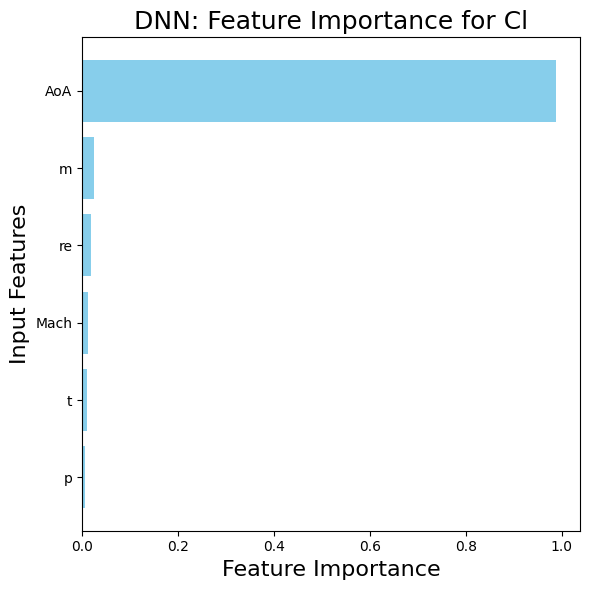

In [111]:
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, RegressorMixin

# Define a wrapper to make your Keras model compatible with sklearn
class ANNWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model):
        self.model = model

    def fit(self, X, y):
        return self

    def predict(self, X):
        # Predict only one output at a time for permutation importance
        return self.model.predict(X).reshape(-1, 3)

# Instantiate the wrapper
wrapped_model = ANNWrapper(dnn)

# Select which output to evaluate feature importance for (0 = Cl, 1 = Cd, 2 = Cm)
target_index = 0  # Change to 1 or 2 for Cd or Cm

# Compute permutation importance
def custom_scorer(estimator, X, y):
    y_pred = estimator.predict(X)[:, target_index]
    y_true = y.iloc[:, target_index] if isinstance(y, pd.DataFrame) else y[:, target_index]
    return -mean_squared_error(y_true, y_pred)  # negative MSE for scoring

result = permutation_importance(
    wrapped_model, X_test, y_test,
    n_repeats=10,
    random_state=0,
    scoring=custom_scorer
)

# Prepare the feature names and importance
importance = result.importances_mean
feature_names = X.columns

# Sort features by importance
sorted_indices = np.argsort(importance)
sorted_importance = importance[sorted_indices]
sorted_feature_names = feature_names[sorted_indices]
# Plotting
plt.figure(figsize=(6, 6))
plt.barh(sorted_feature_names, sorted_importance, color='skyblue')
plt.xlabel('Feature Importance', fontsize=16)
plt.ylabel('Input Features', fontsize=16)
plt.title(f'DNN: Feature Importance for {["Cl", "Cd", "Cm"][target_index]}', fontsize=18)
plt.grid(False) # , linestyle='--', linewidth=0.5
plt.tight_layout()
plt.show()

Cd Prediction

696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 597us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 570us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 579us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 571us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 593us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 574us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 580us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 576us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 567us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 567us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 571us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 573us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 567us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 581us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 564us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 570us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 576us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 569us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step
696/696 ━━━

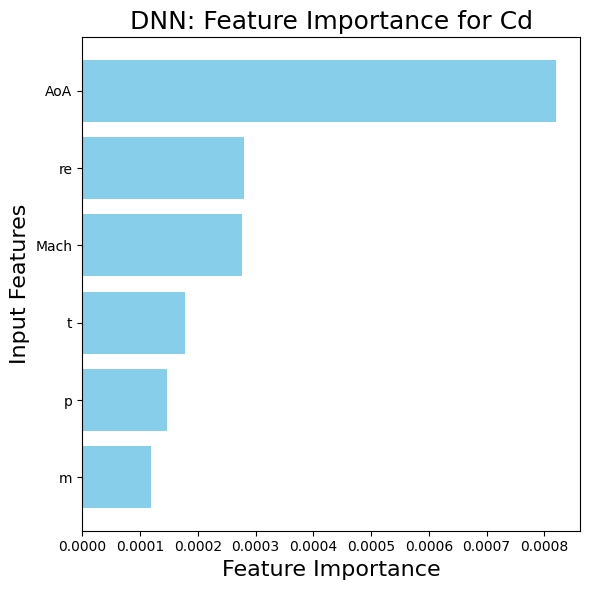

In [112]:
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, RegressorMixin

# Define a wrapper to make your Keras model compatible with sklearn
class ANNWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model):
        self.model = model

    def fit(self, X, y):
        return self

    def predict(self, X):
        # Predict only one output at a time for permutation importance
        return self.model.predict(X).reshape(-1, 3)

# Instantiate the wrapper
wrapped_model = ANNWrapper(dnn)

# Select which output to evaluate feature importance for (0 = Cl, 1 = Cd, 2 = Cm)
target_index = 1  # Change to 1 or 2 for Cd or Cm

# Compute permutation importance
def custom_scorer(estimator, X, y):
    y_pred = estimator.predict(X)[:, target_index]
    y_true = y.iloc[:, target_index] if isinstance(y, pd.DataFrame) else y[:, target_index]
    return -mean_squared_error(y_true, y_pred)  # negative MSE for scoring

result = permutation_importance(
    wrapped_model, X_test, y_test,
    n_repeats=10,
    random_state=0,
    scoring=custom_scorer
)

# Prepare the feature names and importance
importance = result.importances_mean
feature_names = X.columns

# Sort features by importance
sorted_indices = np.argsort(importance)
sorted_importance = importance[sorted_indices]
sorted_feature_names = feature_names[sorted_indices]

# Plotting
plt.figure(figsize=(6, 6))
plt.barh(sorted_feature_names, sorted_importance, color='skyblue')
plt.xlabel('Feature Importance', fontsize=16)
plt.ylabel('Input Features', fontsize=16)
plt.title(f'DNN: Feature Importance for {["Cl", "Cd", "Cm"][target_index]}', fontsize=18)
plt.grid(False) # , linestyle='--', linewidth=0.5
plt.tight_layout()
plt.show()


Cm Prediction

696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 599us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 567us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 567us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 560us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 579us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 563us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 564us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 567us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 564us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 573us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 564us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 563us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 567us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 571us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 570us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 561us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 561us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 566us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step
696/696 ━━━

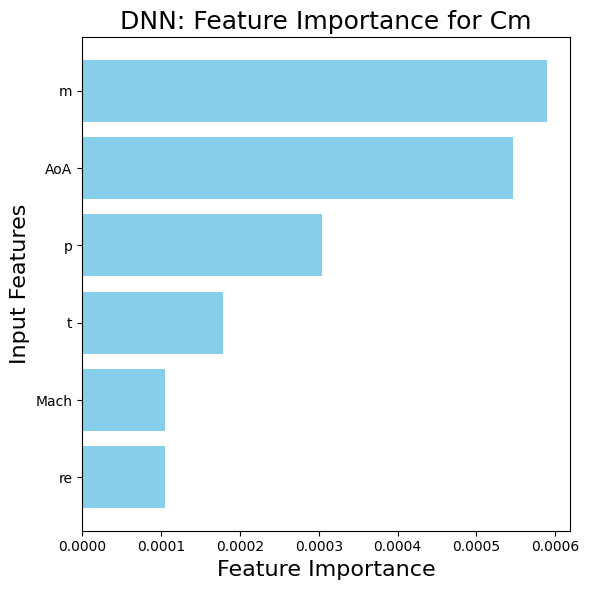

In [113]:
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, RegressorMixin

# Define a wrapper to make your Keras model compatible with sklearn
class ANNWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model):
        self.model = model

    def fit(self, X, y):
        return self

    def predict(self, X):
        # Predict only one output at a time for permutation importance
        return self.model.predict(X).reshape(-1, 3)

# Instantiate the wrapper
wrapped_model = ANNWrapper(dnn)

# Select which output to evaluate feature importance for (0 = Cl, 1 = Cd, 2 = Cm)
target_index = 2  # Change to 1 or 2 for Cd or Cm

# Compute permutation importance
def custom_scorer(estimator, X, y):
    y_pred = estimator.predict(X)[:, target_index]
    y_true = y.iloc[:, target_index] if isinstance(y, pd.DataFrame) else y[:, target_index]
    return -mean_squared_error(y_true, y_pred)  # negative MSE for scoring

result = permutation_importance(
    wrapped_model, X_test, y_test,
    n_repeats=10,
    random_state=0,
    scoring=custom_scorer
)

# Prepare the feature names and importance
importance = result.importances_mean
feature_names = X.columns

# Sort features by importance
sorted_indices = np.argsort(importance)
sorted_importance = importance[sorted_indices]
sorted_feature_names = feature_names[sorted_indices]
# Plotting
plt.figure(figsize=(6, 6))
plt.barh(sorted_feature_names, sorted_importance, color='skyblue')
plt.xlabel('Feature Importance', fontsize=16)
plt.ylabel('Input Features', fontsize=16)
plt.title(f'DNN: Feature Importance for {["Cl", "Cd", "Cm"][target_index]}', fontsize=18)
plt.grid(False)
plt.tight_layout()
plt.show()

#### Random Forest

Cl Prediction

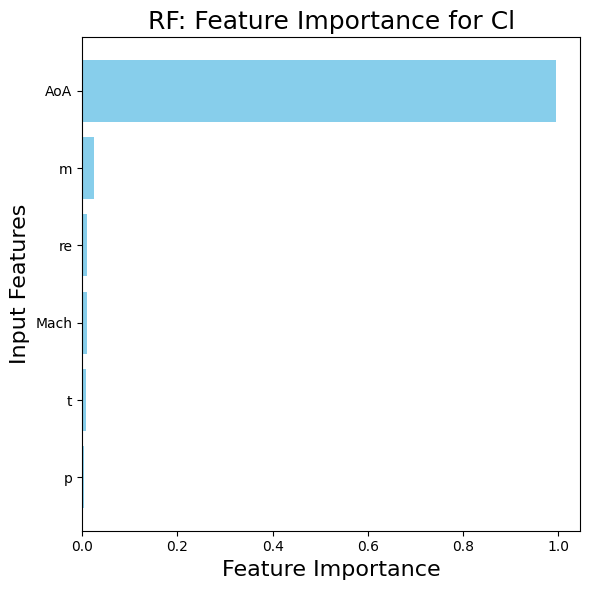

In [114]:
from sklearn.inspection import permutation_importance

# Choose output (0 = Cl, 1 = Cd, 2 = Cm)
target_index = 0

# Updated custom scorer
def custom_scorer_rf(estimator, X, y):
    y_pred = estimator.predict(X)
    
    if isinstance(y, pd.DataFrame):
        y_true = y.iloc[:, target_index]
        y_pred = y_pred[:, target_index]
    else:
        y_true = y[:, target_index]
        y_pred = y_pred[:, target_index]
        
    return -mean_squared_error(y_true, y_pred)

# Compute permutation importance
rf_result = permutation_importance(
    rf, X_test, y_test,  # use your trained RF model here
    n_repeats=10,
    random_state=0,
    scoring=custom_scorer_rf
)

# Prepare data
importance = rf_result.importances_mean
feature_names = X.columns

sorted_indices = np.argsort(importance)
sorted_importance = importance[sorted_indices]
sorted_feature_names = feature_names[sorted_indices]

# Plot
plt.figure(figsize=(6, 6))
plt.barh(sorted_feature_names, sorted_importance, color='skyblue')
plt.xlabel('Feature Importance', fontsize=16)
plt.ylabel('Input Features', fontsize=16)
plt.title(f'RF: Feature Importance for {["Cl", "Cd", "Cm"][target_index]}', fontsize=18)
plt.grid(False)
plt.tight_layout()
plt.show()


Cd Prediction

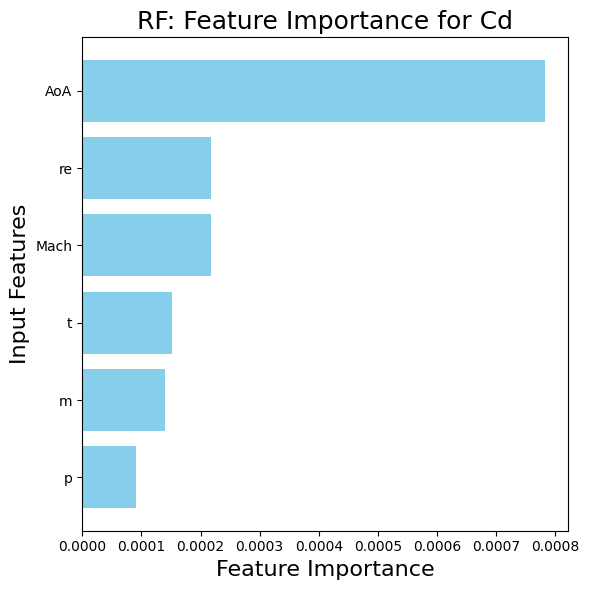

In [116]:
from sklearn.inspection import permutation_importance

# Choose output (0 = Cl, 1 = Cd, 2 = Cm)
target_index = 1

# Updated custom scorer
def custom_scorer_rf(estimator, X, y):
    y_pred = estimator.predict(X)
    
    if isinstance(y, pd.DataFrame):
        y_true = y.iloc[:, target_index]
        y_pred = y_pred[:, target_index]
    else:
        y_true = y[:, target_index]
        y_pred = y_pred[:, target_index]
        
    return -mean_squared_error(y_true, y_pred)

# Compute permutation importance
rf_result = permutation_importance(
    rf, X_test, y_test,  # use your trained RF model here
    n_repeats=10,
    random_state=0,
    scoring=custom_scorer_rf
)

# Prepare data
importance = rf_result.importances_mean
feature_names = X.columns

sorted_indices = np.argsort(importance)
sorted_importance = importance[sorted_indices]
sorted_feature_names = feature_names[sorted_indices]

# Plot
plt.figure(figsize=(6, 6))
plt.barh(sorted_feature_names, sorted_importance, color='skyblue')
plt.xlabel('Feature Importance', fontsize=16)
plt.ylabel('Input Features', fontsize=16)
plt.title(f'RF: Feature Importance for {["Cl", "Cd", "Cm"][target_index]}', fontsize=18)
plt.grid(False)
plt.tight_layout()
plt.show()


Cm Prediction

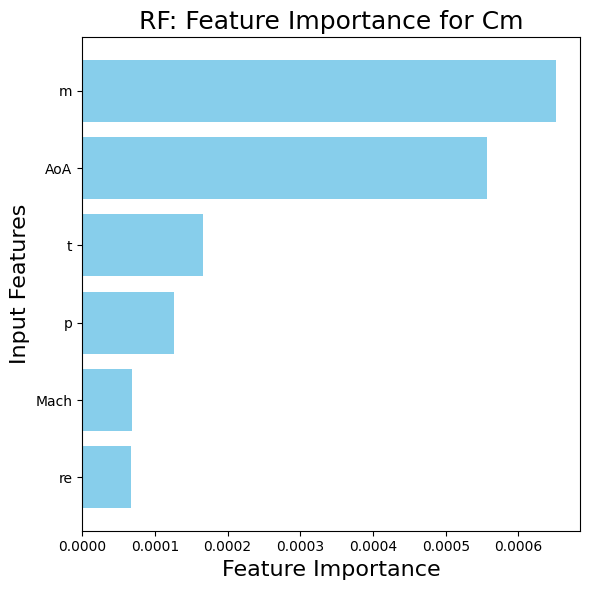

In [117]:
from sklearn.inspection import permutation_importance

# Choose output (0 = Cl, 1 = Cd, 2 = Cm)
target_index = 2

# Updated custom scorer
def custom_scorer_rf(estimator, X, y):
    y_pred = estimator.predict(X)
    
    if isinstance(y, pd.DataFrame):
        y_true = y.iloc[:, target_index]
        y_pred = y_pred[:, target_index]
    else:
        y_true = y[:, target_index]
        y_pred = y_pred[:, target_index]
        
    return -mean_squared_error(y_true, y_pred)

# Compute permutation importance
rf_result = permutation_importance(
    rf, X_test, y_test,  # use your trained RF model here
    n_repeats=10,
    random_state=0,
    scoring=custom_scorer_rf
)

# Prepare data
importance = rf_result.importances_mean
feature_names = X.columns

sorted_indices = np.argsort(importance)
sorted_importance = importance[sorted_indices]
sorted_feature_names = feature_names[sorted_indices]

# Plot
plt.figure(figsize=(6, 6))
plt.barh(sorted_feature_names, sorted_importance, color='skyblue')
plt.xlabel('Feature Importance', fontsize=16)
plt.ylabel('Input Features', fontsize=16)
plt.title(f'RF: Feature Importance for {["Cl", "Cd", "Cm"][target_index]}', fontsize=18)
plt.grid(False)
plt.tight_layout()
plt.show()


#### Gradient Boosting

Cl Predition

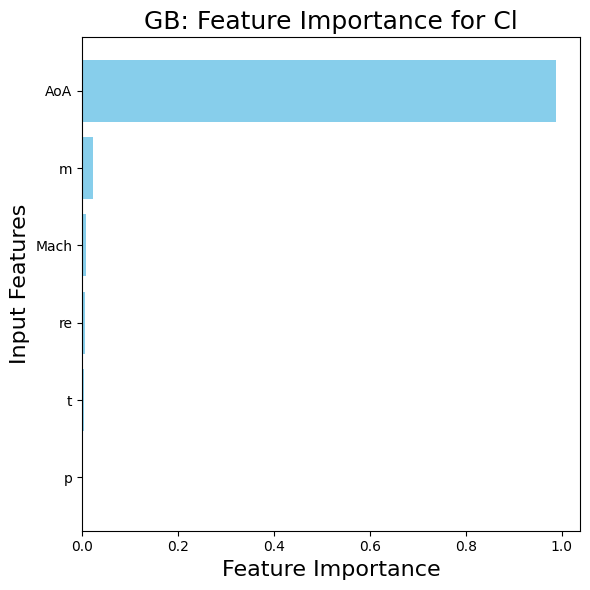

In [118]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Change this index to 0 (Cl), 1 (Cd), or 2 (Cm) as needed
target_index = 0  # 0 = Cl, 1 = Cd, 2 = Cm

# Ensure y_test is a NumPy array for slicing
if isinstance(y_test, pd.DataFrame):
    y_test_array = y_test.values
else:
    y_test_array = y_test

def custom_scorer_gb(estimator, X, y):
    y_pred = estimator.predict(X)
    return -mean_squared_error(y[:, target_index], y_pred[:, target_index])

gb_result = permutation_importance(
    gb, X_test, y_test_array,
    n_repeats=10,
    random_state=0,
    scoring=custom_scorer_gb
)

importance = gb_result.importances_mean
feature_names = X.columns

sorted_indices = np.argsort(importance)
sorted_importance = importance[sorted_indices]
sorted_feature_names = feature_names[sorted_indices]

plt.figure(figsize=(6, 6))
plt.barh(sorted_feature_names, sorted_importance, color='skyblue')
plt.xlabel('Feature Importance', fontsize=16)
plt.ylabel('Input Features', fontsize=16)
plt.title(f'GB: Feature Importance for {["Cl", "Cd", "Cm"][target_index]}', fontsize=18)
plt.grid(False)
plt.tight_layout()
plt.show()


Cd Prediction

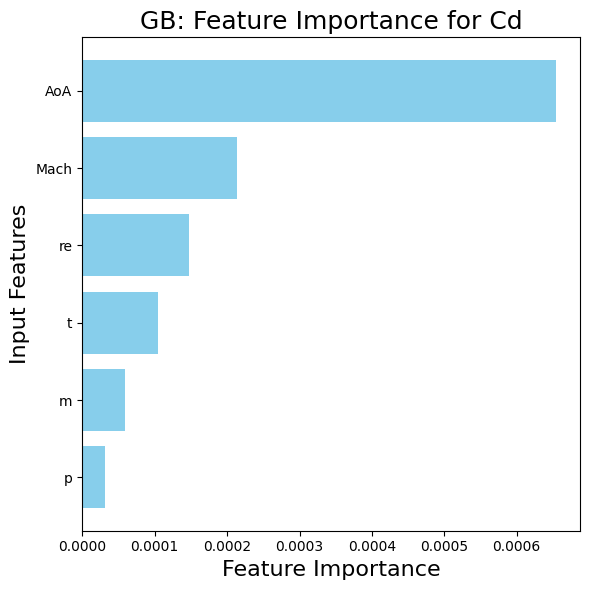

In [119]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Change this index to 0 (Cl), 1 (Cd), or 2 (Cm) as needed
target_index = 1  # 0 = Cl, 1 = Cd, 2 = Cm

# Ensure y_test is a NumPy array for slicing
if isinstance(y_test, pd.DataFrame):
    y_test_array = y_test.values
else:
    y_test_array = y_test

def custom_scorer_gb(estimator, X, y):
    y_pred = estimator.predict(X)
    return -mean_squared_error(y[:, target_index], y_pred[:, target_index])

gb_result = permutation_importance(
    gb, X_test, y_test_array,
    n_repeats=10,
    random_state=0,
    scoring=custom_scorer_gb
)

importance = gb_result.importances_mean
feature_names = X.columns

sorted_indices = np.argsort(importance)
sorted_importance = importance[sorted_indices]
sorted_feature_names = feature_names[sorted_indices]

plt.figure(figsize=(6, 6))
plt.barh(sorted_feature_names, sorted_importance, color='skyblue')
plt.xlabel('Feature Importance', fontsize=16)
plt.ylabel('Input Features', fontsize=16)
plt.title(f'GB: Feature Importance for {["Cl", "Cd", "Cm"][target_index]}', fontsize=18)
plt.grid(False)
plt.tight_layout()
plt.show()


Cm Prediction

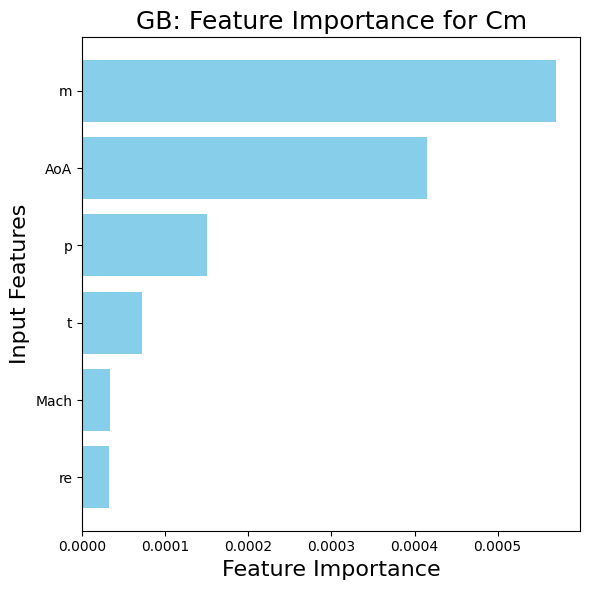

In [120]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Change this index to 0 (Cl), 1 (Cd), or 2 (Cm) as needed
target_index = 2  # 0 = Cl, 1 = Cd, 2 = Cm

# Ensure y_test is a NumPy array for slicing
if isinstance(y_test, pd.DataFrame):
    y_test_array = y_test.values
else:
    y_test_array = y_test

def custom_scorer_gb(estimator, X, y):
    y_pred = estimator.predict(X)
    return -mean_squared_error(y[:, target_index], y_pred[:, target_index])

gb_result = permutation_importance(
    gb, X_test, y_test_array,
    n_repeats=10,
    random_state=0,
    scoring=custom_scorer_gb
)

importance = gb_result.importances_mean
feature_names = X.columns

sorted_indices = np.argsort(importance)
sorted_importance = importance[sorted_indices]
sorted_feature_names = feature_names[sorted_indices]

plt.figure(figsize=(6, 6))
plt.barh(sorted_feature_names, sorted_importance, color='skyblue')
plt.xlabel('Feature Importance', fontsize=16)
plt.ylabel('Input Features', fontsize=16)
plt.title(f'GB: Feature Importance for {["Cl", "Cd", "Cm"][target_index]}', fontsize=18)
plt.grid(False)
plt.tight_layout()
plt.show()


#### Polynomial Regression

Cl Prediction

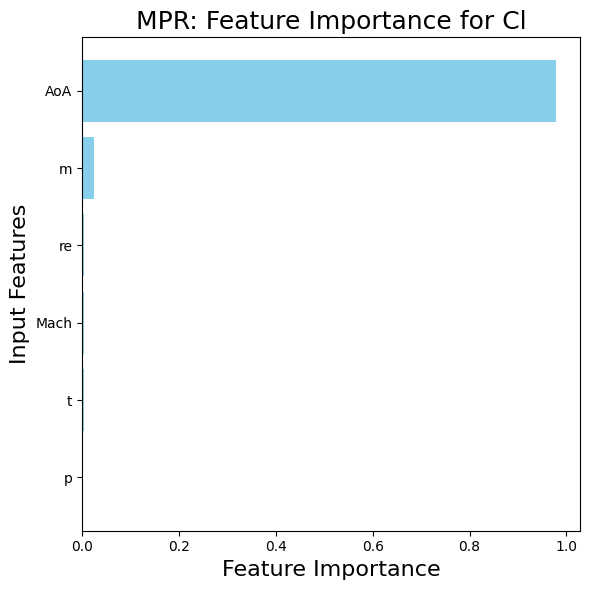

In [121]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Change this index to 0 (Cl), 1 (Cd), or 2 (Cm) as needed
target_index = 0  # 0 = Cl, 1 = Cd, 2 = Cm

# Ensure y_test is a NumPy array for slicing
if isinstance(y_test, pd.DataFrame):
    y_test_array = y_test.values
else:
    y_test_array = y_test

def custom_scorer_pr(estimator, X, y):
    y_pred = estimator.predict(X)
    return -mean_squared_error(y[:, target_index], y_pred[:, target_index])

pr_result = permutation_importance(
    poly, X_test, y_test_array,
    n_repeats=10,
    random_state=0,
    scoring=custom_scorer_pr
)

importance = pr_result.importances_mean
feature_names = X.columns

sorted_indices = np.argsort(importance)
sorted_importance = importance[sorted_indices]
sorted_feature_names = feature_names[sorted_indices]

plt.figure(figsize=(6, 6))
plt.barh(sorted_feature_names, sorted_importance, color='skyblue')
plt.xlabel('Feature Importance', fontsize=16)
plt.ylabel('Input Features', fontsize=16)
plt.title(f'MPR: Feature Importance for {["Cl", "Cd", "Cm"][target_index]}', fontsize=18)
plt.grid(False)
plt.tight_layout()
plt.show()


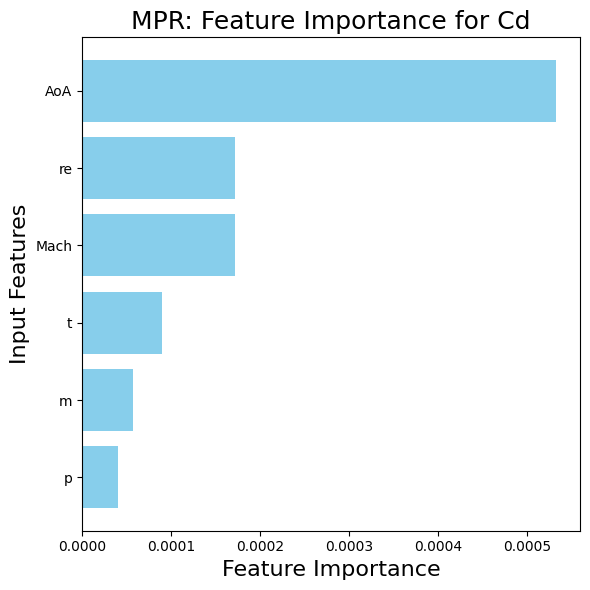

In [122]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Change this index to 0 (Cl), 1 (Cd), or 2 (Cm) as needed
target_index = 1  # 0 = Cl, 1 = Cd, 2 = Cm

# Ensure y_test is a NumPy array for slicing
if isinstance(y_test, pd.DataFrame):
    y_test_array = y_test.values
else:
    y_test_array = y_test

def custom_scorer_pr(estimator, X, y):
    y_pred = estimator.predict(X)
    return -mean_squared_error(y[:, target_index], y_pred[:, target_index])

pr_result = permutation_importance(
    poly, X_test, y_test_array,
    n_repeats=10,
    random_state=0,
    scoring=custom_scorer_pr
)

importance = pr_result.importances_mean
feature_names = X.columns

sorted_indices = np.argsort(importance)
sorted_importance = importance[sorted_indices]
sorted_feature_names = feature_names[sorted_indices]

plt.figure(figsize=(6, 6))
plt.barh(sorted_feature_names, sorted_importance, color='skyblue')
plt.xlabel('Feature Importance', fontsize=16)
plt.ylabel('Input Features', fontsize=16)
plt.title(f'MPR: Feature Importance for {["Cl", "Cd", "Cm"][target_index]}', fontsize=18)
plt.grid(False)
plt.tight_layout()
plt.show()


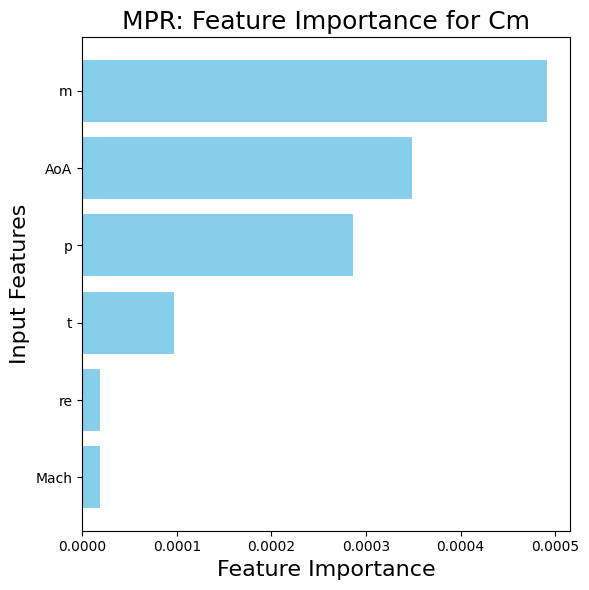

In [123]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Change this index to 0 (Cl), 1 (Cd), or 2 (Cm) as needed
target_index = 2  # 0 = Cl, 1 = Cd, 2 = Cm

# Ensure y_test is a NumPy array for slicing
if isinstance(y_test, pd.DataFrame):
    y_test_array = y_test.values
else:
    y_test_array = y_test

def custom_scorer_pr(estimator, X, y):
    y_pred = estimator.predict(X)
    return -mean_squared_error(y[:, target_index], y_pred[:, target_index])

pr_result = permutation_importance(
    poly, X_test, y_test_array,
    n_repeats=10,
    random_state=0,
    scoring=custom_scorer_pr
)

importance = pr_result.importances_mean
feature_names = X.columns

sorted_indices = np.argsort(importance)
sorted_importance = importance[sorted_indices]
sorted_feature_names = feature_names[sorted_indices]

plt.figure(figsize=(6, 6))
plt.barh(sorted_feature_names, sorted_importance, color='skyblue')
plt.xlabel('Feature Importance', fontsize=16)
plt.ylabel('Input Features', fontsize=16)
plt.title(f'MPR: Feature Importance for {["Cl", "Cd", "Cm"][target_index]}', fontsize=18)
plt.grid(False)
plt.tight_layout()
plt.show()


In [ ]:
# # Example input: [m, p, t, Mach, re, AoA]
# new_condition = np.array([[0.03, 0.3, 0.09, 0.000435, 10000, 11.5]])  # Replace values with your desired condition

# # Scale the input using the same scaler used during training
# new_condition_scaled = sc.transform(new_condition)

# # Predict Cl, Cd, Cm
# predicted_output = dnn.predict(new_condition_scaled)

# # Extract the values
# predicted_Cl = predicted_output[0][0]
# predicted_Cd = predicted_output[0][1]
# predicted_Cm = predicted_output[0][2]

# # Print the results
# print(f"Predicted Cl: {predicted_Cl:.5f}")
# print(f"Predicted Cd: {predicted_Cd:.5f}")
# print(f"Predicted Cm: {predicted_Cm:.5f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Predicted Cl: 0.62295
Predicted Cd: 0.14680
Predicted Cm: -0.08321


d:\NIHUT NAMAZ\Airfoil\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
